In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
# Turn off automatic display in Jupyter notebook to prevent showing empty figures
plt.ioff()

from metrics import equal_interval_ece, classwise_ece, canonical_ece
from losses import ECLossMiniBatch, soft_binning_ece
from networks import SimpleNet
from utils import (
    initFun, plt_Reliability_Diagram, plt_canonical_Calibration_Reliability_Diagram,
    plot_data, labeling_function, fontsize
)


In [2]:
# Configuration
calibration_paradigm = "TopLabel"  # Options: "TopLabel", "Classwise", "Canonical"
fig_dist, ax1, ax2, fig_rel, ax3, ax4, ax5 = initFun(calibration_paradigm)


In [3]:
# Data generation based on calibration paradigm
if calibration_paradigm == "TopLabel":
    # TopLabel
    is_normal = False
    dim = 100
    batch_size = 200
    num_samples = 400
    lamb = 0.5
    Using_Source_Calibration = True

    if is_normal:
        # normal distribution
        mean_train = [0, 0]
        cov_train  = [[5, 0], [0, 5]]
        X_train = np.random.multivariate_normal(mean_train, cov_train, num_samples)
    else:
        # uniform distribution
        X_train = np.random.uniform(-2.5, 2.5, size=(num_samples, 2))
        mean_train = None
    y_train = labeling_function(X_train)
    plot_data(ax1, X_train, y_train, is_normal, mean=mean_train)

    # Build test data
    if is_normal:
        # normal distribution
        mean_test = [2, 2]
        cov_test  = [[5, 0], [0, 5]]
        X_test = np.random.multivariate_normal(mean_test, cov_test, num_samples)
    else:
        # uniform distribution
        X_test = np.random.uniform(-1.5, 3.5, size=(num_samples, 2))
        mean_test = None
    y_test = labeling_function(X_test)
    plot_data(ax2, X_test, y_test, is_normal, mean=mean_test)

elif calibration_paradigm == "Classwise":
    # Classwise
    is_normal = False
    dim = 100
    batch_size = 100
    num_samples = 600
    lamb = 0.5
    Using_Source_Calibration = False

    if is_normal:
        # normal distribution
        mean_train = [0, 0]
        cov_train  = [[6, 0], [0, 6]]
        X_train = np.random.multivariate_normal(mean_train, cov_train, num_samples)
    else:
        # uniform distribution
        X_train = np.random.uniform(-3, 3, size=(num_samples, 2))
        mean_train = None
    y_train = labeling_function(X_train)
    plot_data(ax1, X_train, y_train, is_normal, mean=mean_train)
    plot_class_idx = 1

    # Build test data
    if is_normal:
        # normal distribution
        mean_test = [2, 2]
        cov_test  = [[6, 0], [0, 6]]
        X_test = np.random.multivariate_normal(mean_test, cov_test, num_samples)
    else:
        # uniform distribution
        X_test = np.random.uniform(-1, 4, size=(num_samples, 2))
        mean_test = None
    y_test = labeling_function(X_test)
    plot_data(ax2, X_test, y_test, is_normal, mean=mean_test)
else:
    # Canonical calibration
    is_normal = False
    dim = 300
    batch_size = 100
    num_samples = 800
    lamb = 10
    Using_Source_Calibration = False

    if is_normal:
        # normal distribution
        mean_train = [0, 0]
        cov_train  = [[6, 0], [0, 6]]
        X_train = np.random.multivariate_normal(mean_train, cov_train, num_samples)
    else:
        # uniform distribution
        X_train = np.random.uniform(-3, 3, size=(num_samples, 2))
        mean_train = None
    y_train = labeling_function(X_train)
    plot_data(ax1, X_train, y_train, is_normal, mean=mean_train)
    plot_class_idx = 1

    # Build test data
    if is_normal:
        # normal distribution
        mean_test = [2, 2]
        cov_test  = [[6, 0], [0, 6]]
        X_test = np.random.multivariate_normal(mean_test, cov_test, num_samples)
    else:
        # uniform distribution
        X_test = np.random.uniform(-1, 4, size=(num_samples, 2))
        mean_test = None
    y_test = labeling_function(X_test)
    plot_data(ax2, X_test, y_test, is_normal, mean=mean_test)

# Create a single shared legend for the two distribution axes (Source & Target)
handles, labels = ax1.get_legend_handles_labels()
if len(handles) > 0:
    fig_dist.legend(handles, labels, loc='lower center', ncol=len(labels),
                    prop={"family": "Times New Roman", "size": fontsize}, markerscale=3)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [4]:
# Training without calibration
model = SimpleNet(dim, num_classes=3, calibration_paradigm=calibration_paradigm)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
lr_sche = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100,150], gamma=0.1)
num_epochs = 200
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        train_preds = torch.argmax(outputs, dim=1)
        train_probs = torch.softmax(outputs, dim=1).max(dim=1).values
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    lr_sche.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss / len(train_loader):.4f}")
model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs_all = torch.softmax(test_logits, dim=1)
    test_preds = torch.argmax(test_probs_all, dim=1).cpu().numpy()
    test_labels = y_test_tensor.cpu().numpy()
    test_accuracy = np.mean(test_preds == test_labels)
    print("Test Accuracy: {:.4f}".format(test_accuracy))
    test_probs = test_probs_all.max(dim=1).values.cpu().numpy()

# Compute ECE and plot reliability diagram
if calibration_paradigm == "TopLabel":
    ece, bins, bin_confs, bin_accs, bin_counts = equal_interval_ece(test_probs, test_preds==test_labels, num_bins=15)
    plt_Reliability_Diagram(ax3, bins, bin_confs, bin_accs, ece, test_accuracy, bin_counts)
elif calibration_paradigm == "Classwise":
    ece, bins, bin_confs, bin_accs, bin_counts = classwise_ece(test_probs_all.cpu().numpy(), test_labels, num_bins=15, plot_class_idx=plot_class_idx)
    plt_Reliability_Diagram(ax3, bins, bin_confs, bin_accs, ece, test_accuracy, bin_counts, calibration_paradigm)
else:
    # Canonical calibration
    ece, ece_in_anchors, counts_in_anchors = canonical_ece(test_probs_all.cpu().numpy(), test_labels)
    plt_canonical_Calibration_Reliability_Diagram(ax3, ece, ece_in_anchors, counts_in_anchors, test_accuracy=test_accuracy)


Epoch 10/200, Loss: 0.1873
Epoch 20/200, Loss: 0.0979
Epoch 30/200, Loss: 0.0690
Epoch 40/200, Loss: 0.0539
Epoch 50/200, Loss: 0.0446
Epoch 60/200, Loss: 0.0385
Epoch 70/200, Loss: 0.0337
Epoch 80/200, Loss: 0.0300
Epoch 90/200, Loss: 0.0271
Epoch 100/200, Loss: 0.0246
Epoch 110/200, Loss: 0.0240
Epoch 120/200, Loss: 0.0238
Epoch 130/200, Loss: 0.0236
Epoch 140/200, Loss: 0.0233
Epoch 150/200, Loss: 0.0231
Epoch 160/200, Loss: 0.0230
Epoch 170/200, Loss: 0.0230
Epoch 180/200, Loss: 0.0230
Epoch 190/200, Loss: 0.0230
Epoch 200/200, Loss: 0.0229
Test Accuracy: 0.9575


In [5]:
# Train with Soft-ECE loss
model2 = SimpleNet(100, num_classes=3, calibration_paradigm=calibration_paradigm)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.01)
lr_sche = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100,150], gamma=0.1)
num_epochs = 200
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model2(batch_X)
        loss = criterion(outputs, batch_y)
        train_preds = torch.argmax(outputs, dim=1)
        train_probs = torch.softmax(outputs, dim=1).max(dim=1).values
        ece = soft_binning_ece(outputs, train_preds==batch_y)
        loss = loss + ece
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    lr_sche.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss / len(train_loader):.4f}")
model2.eval()
with torch.no_grad():
    test_logits = model2(X_test_tensor)
    test_probs_all = torch.softmax(test_logits, dim=1)
    test_preds = torch.argmax(test_probs_all, dim=1).cpu().numpy()
    test_labels = y_test_tensor.cpu().numpy()
    test_accuracy = np.mean(test_preds == test_labels)
    print("Test Accuracy: {:.4f}".format(test_accuracy))
    test_probs = test_probs_all.max(dim=1).values.cpu().numpy()

# Compute ECE and plot reliability diagram
if calibration_paradigm == "TopLabel":
    ece, bins, bin_confs, bin_accs, bin_counts = equal_interval_ece(test_probs, test_preds==test_labels, num_bins=15)
    plt_Reliability_Diagram(ax4, bins, bin_confs, bin_accs, ece, test_accuracy, bin_counts)
elif calibration_paradigm == "Classwise":
    ece, bins, bin_confs, bin_accs, bin_counts = classwise_ece(test_probs_all.cpu().numpy(), test_labels, num_bins=15, plot_class_idx=plot_class_idx)
    plt_Reliability_Diagram(ax4, bins, bin_confs, bin_accs, ece, test_accuracy, bin_counts, calibration_paradigm)
else:
    # Canonical calibration
    ece, ece_in_anchors, counts_in_anchors = canonical_ece(test_probs_all.cpu().numpy(), test_labels)
    plt_canonical_Calibration_Reliability_Diagram(ax4, ece, ece_in_anchors, counts_in_anchors, test_accuracy=test_accuracy)


Epoch 10/200, Loss: 0.2485
Epoch 20/200, Loss: 0.1389
Epoch 30/200, Loss: 0.1251
Epoch 40/200, Loss: 0.1282
Epoch 50/200, Loss: 0.1254
Epoch 60/200, Loss: 0.0713
Epoch 70/200, Loss: 0.0709
Epoch 80/200, Loss: 0.0816
Epoch 90/200, Loss: 0.0726
Epoch 100/200, Loss: 0.0657
Epoch 110/200, Loss: 0.0636
Epoch 120/200, Loss: 0.0601
Epoch 130/200, Loss: 0.0600
Epoch 140/200, Loss: 0.0589
Epoch 150/200, Loss: 0.0583
Epoch 160/200, Loss: 0.0560
Epoch 170/200, Loss: 0.0553
Epoch 180/200, Loss: 0.0568
Epoch 190/200, Loss: 0.0556
Epoch 200/200, Loss: 0.0585
Test Accuracy: 0.9500


In [ ]:
# Training Classification Head
if calibration_paradigm == "TopLabel":
    model.train()
    optimizer2 = torch.optim.Adam(model.classifier2.parameters(), lr=0.01)
    num_epochs = 100
    for epoch in range(num_epochs):
        epoch_loss2 = 0.0
        for batch_X, batch_y in train_loader:
            with torch.no_grad():
                preds = torch.argmax(model(batch_X), dim=1).detach()
            optimizer2.zero_grad()
            outputs2 = model.forward_classifier2(batch_X)
            loss2 = torch.nn.functional.cross_entropy(outputs2, (preds==batch_y).long())

            if Using_Source_Calibration:
                ece = soft_binning_ece(outputs2, preds==batch_y)
                loss2 += ece
                
            loss2.backward()
            optimizer2.step()
            epoch_loss2 += loss2.item()
        if (epoch+1) % 10 == 0:
            print(f"(Classifier2) Epoch {epoch+1}/{num_epochs}, Loss2: {epoch_loss2 / len(train_loader):.4f}")
else:
    model.train()
    optimizer2 = torch.optim.Adam(model.classifier2.parameters(), lr=0.01)
    num_epochs = 100
    for epoch in range(num_epochs):
        epoch_loss2 = 0.0
        for batch_X, batch_y in train_loader:
            optimizer2.zero_grad()
            outputs2 = model.forward_classifier2(batch_X)
            loss2 = torch.nn.functional.cross_entropy(outputs2, batch_y)

            if Using_Source_Calibration:
                ece = soft_binning_ece(outputs2, batch_y)
                loss2 += ece

            loss2.backward()
            optimizer2.step()
            epoch_loss2 += loss2.item()
        if (epoch+1) % 10 == 0:
            print(f"(Classifier2) Epoch {epoch+1}/{num_epochs}, Loss2: {epoch_loss2 / len(train_loader):.4f}")


(Classifier2) Epoch 10/100, Loss2: 0.0201
(Classifier2) Epoch 20/100, Loss2: 0.0219
(Classifier2) Epoch 30/100, Loss2: 0.0213
(Classifier2) Epoch 40/100, Loss2: 0.0202
(Classifier2) Epoch 50/100, Loss2: 0.0192
(Classifier2) Epoch 60/100, Loss2: 0.0182
(Classifier2) Epoch 70/100, Loss2: 0.0170
(Classifier2) Epoch 80/100, Loss2: 0.0159
(Classifier2) Epoch 90/100, Loss2: 0.0153
(Classifier2) Epoch 100/100, Loss2: 0.0149


In [7]:
# Train with ECL (Expectation Consistency Loss)
num_epochs = 100
model.train()
optimizer = optim.Adam(model.fc2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

# Instantiate ECLossMiniBatch outside the epoch loop to maintain u_cache state
minibatchLoss = ECLossMiniBatch(calibration_paradigm, num_classes=3)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_accLoss = 0.0
    epoch_ece = 0.0
    epoch_Lce = 0.0
    
    for (train_X, train_y), (test_X, _) in zip(train_loader, test_loader):
        optimizer.zero_grad()
        train_output = model(train_X)
        train_preds = torch.argmax(train_output, dim=1)
        accLoss = criterion(train_output, train_y)
        ece = soft_binning_ece(train_output, train_preds==train_y)
        test_output = model(test_X)
        L_ce = minibatchLoss(train_X, test_X, train_output, test_output, model)
        loss = lamb*accLoss + L_ce
        loss.backward()
        optimizer.step()
        epoch_accLoss += accLoss.item()
        epoch_ece += ece.item()
        epoch_Lce += L_ce.item()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, acLoss: {epoch_accLoss / min(len(train_loader),len(test_loader)):.4f}, ece: {epoch_ece / min(len(train_loader),len(test_loader)):.4f}, L_ce: {epoch_Lce / min(len(train_loader),len(test_loader)):.4f}, Loss: {epoch_loss / min(len(train_loader),len(test_loader)):.4f}")

model.eval()
with torch.no_grad():
    test_output = model(X_test_tensor)
    test_preds = torch.argmax(test_output, dim=1).cpu().numpy()
    test_probs = torch.softmax(test_output, dim=1).max(dim=1).values
    test_labels = y_test_tensor.cpu().numpy()
    test_accuracy = np.mean(test_preds == test_labels)
    print("Test Accuracy: {:.4f}".format(test_accuracy))

# Compute ECE and plot reliability diagram
if calibration_paradigm == "TopLabel":
    ece, bins, bin_confs, bin_accs, bin_counts = equal_interval_ece(test_probs.cpu().detach().numpy(), test_preds == y_test_tensor.cpu().detach().numpy(), num_bins=15)
    plt_Reliability_Diagram(ax5, bins, bin_confs, bin_accs, ece, test_accuracy, bin_counts)
elif calibration_paradigm == "Classwise":
    test_probs_all = torch.softmax(test_output, dim=1)
    ece, bins, bin_confs, bin_accs, bin_counts = classwise_ece(test_probs_all.cpu().detach().numpy(), test_labels, num_bins=15, plot_class_idx=plot_class_idx)
    plt_Reliability_Diagram(ax5, bins, bin_confs, bin_accs, ece, test_accuracy, bin_counts, calibration_paradigm)
else:
    # Canonical calibration
    test_probs_all = torch.softmax(test_output, dim=1)
    ece, ece_in_anchors, counts_in_anchors = canonical_ece(test_probs_all.cpu().detach().numpy(), test_labels, num_bins=15)
    plt_canonical_Calibration_Reliability_Diagram(ax5, ece, ece_in_anchors, counts_in_anchors, test_accuracy=test_accuracy)


Epoch 1/100, acLoss: 0.0232, ece: 0.0287, L_ce: 0.0174, Loss: 0.0290
Epoch 2/100, acLoss: 0.0230, ece: 0.0278, L_ce: 0.0176, Loss: 0.0291
Epoch 3/100, acLoss: 0.0229, ece: 0.0281, L_ce: 0.0176, Loss: 0.0291
Epoch 4/100, acLoss: 0.0228, ece: 0.0277, L_ce: 0.0174, Loss: 0.0288
Epoch 5/100, acLoss: 0.0228, ece: 0.0275, L_ce: 0.0172, Loss: 0.0286
Epoch 6/100, acLoss: 0.0227, ece: 0.0274, L_ce: 0.0171, Loss: 0.0284
Epoch 7/100, acLoss: 0.0227, ece: 0.0270, L_ce: 0.0171, Loss: 0.0284
Epoch 8/100, acLoss: 0.0226, ece: 0.0268, L_ce: 0.0171, Loss: 0.0284
Epoch 9/100, acLoss: 0.0226, ece: 0.0263, L_ce: 0.0170, Loss: 0.0283
Epoch 10/100, acLoss: 0.0225, ece: 0.0257, L_ce: 0.0169, Loss: 0.0281
Epoch 11/100, acLoss: 0.0225, ece: 0.0263, L_ce: 0.0169, Loss: 0.0281
Epoch 12/100, acLoss: 0.0224, ece: 0.0262, L_ce: 0.0169, Loss: 0.0281
Epoch 13/100, acLoss: 0.0224, ece: 0.0264, L_ce: 0.0169, Loss: 0.0281
Epoch 14/100, acLoss: 0.0223, ece: 0.0261, L_ce: 0.0169, Loss: 0.0280
Epoch 15/100, acLoss: 0.0223,

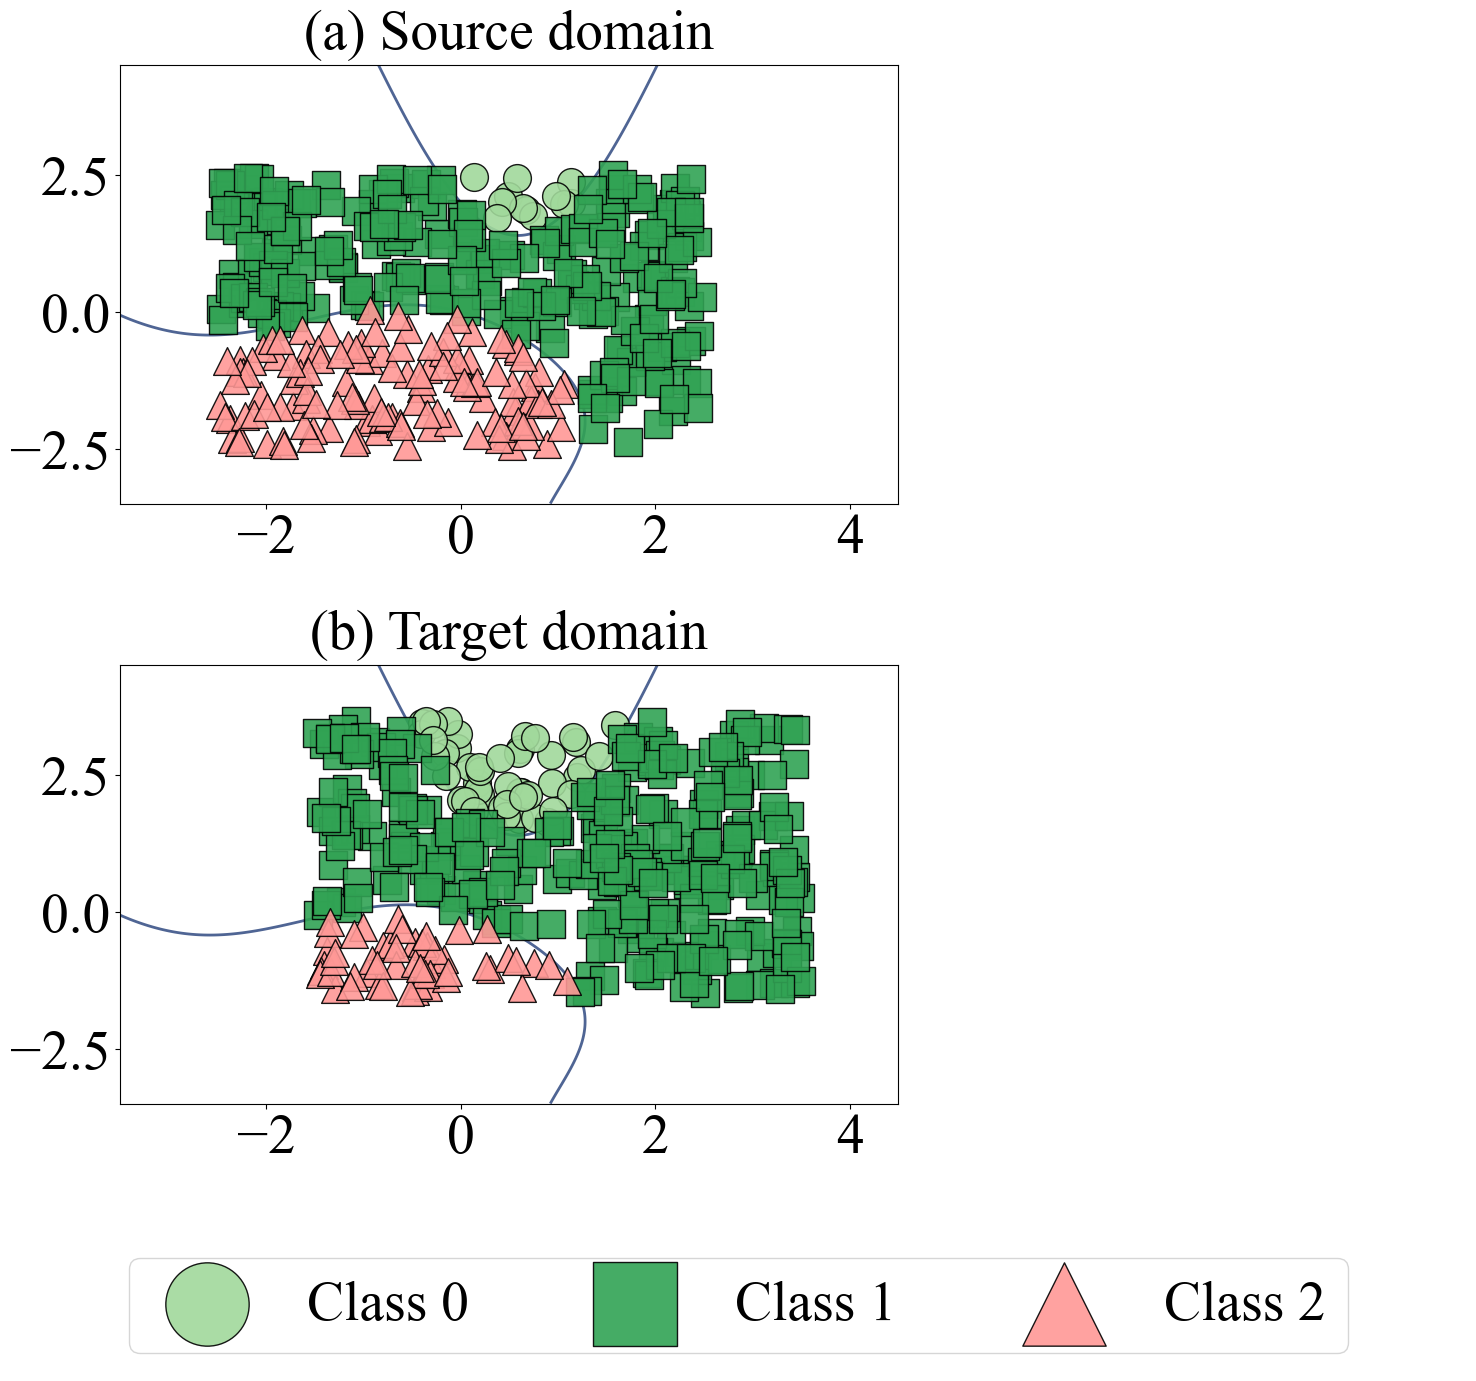

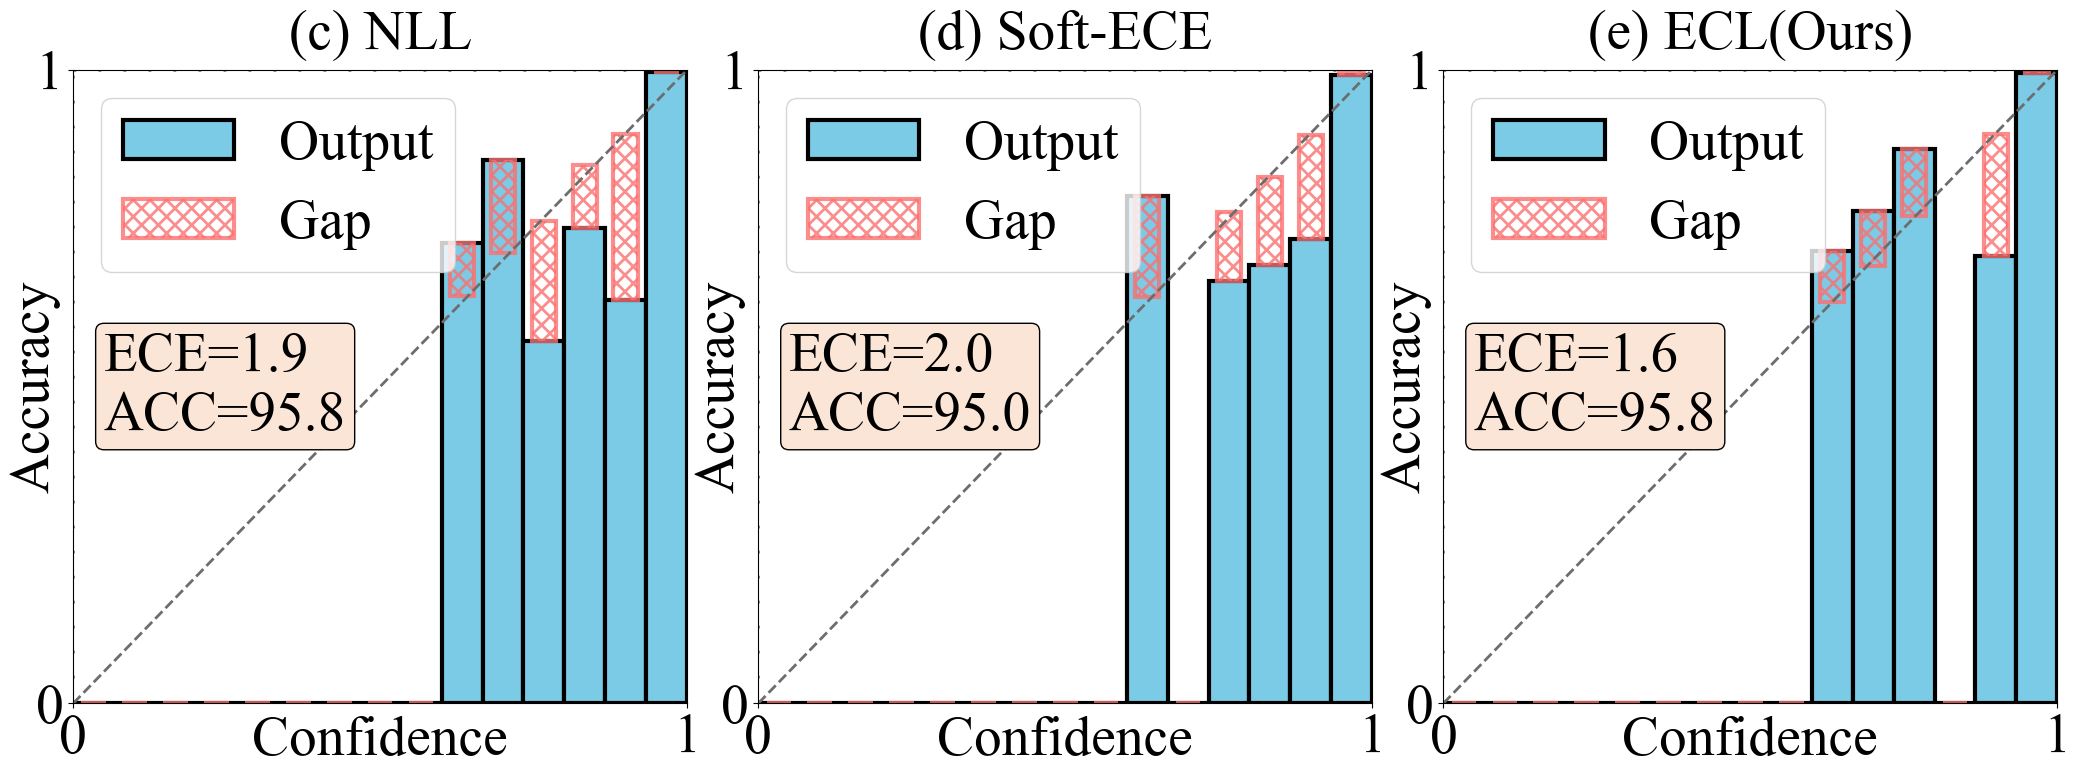

Success!


In [8]:
# Save both figures (distributions and reliability diagrams) separately
fig_dist.set_size_inches(25.6, 14.4)
fig_rel.set_size_inches(25.6, 14.4)

plt.show()
print("Success!")
